# Maximizing Revenue for Taxi Cab Drivers through Payment Type Analysis

# Problem Statement

In the fast-paced taxi booking sector, making the most of revenue is essential for long-term success and driver happiness. Our goal is to use data-driven insights to maximise revenue streams for taxi drivers in order to meet this need. Our research aims to determine whether payment methods have an impact on fare pricing by focusing on the relationship between payment type and fare amount.

# Objective

This project's main goal is to run an A/B test to examine the relationship between the total fare and the method of payment. We use Python hypothesis testing and descriptive statistics to extract useful information that can help taxi drivers generate more cash. In particular, we want to find out if there is a big difference in the fares for those who pay with credit cards versus those who pay with cash.

# Research Question

Is there a relationship between total fare amount and payment type and can we nudge customers towards payment methods that generate higher revenue for drivers, without negatively impacting customer experience?

# Coding


In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as st
import warnings 

warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(r"yellow_tripdata_2020-01.csv")

In [3]:
data.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.20,1.0,N,238,239,1.0,6.00,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.20,1.0,N,239,238,1.0,7.00,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.60,1.0,N,238,238,1.0,6.00,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.80,1.0,N,238,151,1.0,5.50,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.00,1.0,N,193,193,2.0,3.50,0.5,0.5,0.00,0.0,0.3,4.80,0.0
5,2.0,2020-01-01 00:09:44,2020-01-01 00:10:37,1.0,0.03,1.0,N,7,193,2.0,2.50,0.5,0.5,0.00,0.0,0.3,3.80,0.0
6,2.0,2020-01-01 00:39:25,2020-01-01 00:39:29,1.0,0.00,1.0,N,193,193,1.0,2.50,0.5,0.5,0.01,0.0,0.3,3.81,0.0
7,2.0,2019-12-18 15:27:49,2019-12-18 15:28:59,1.0,0.00,5.0,N,193,193,1.0,0.01,0.0,0.0,0.00,0.0,0.3,2.81,2.5
8,2.0,2019-12-18 15:30:35,2019-12-18 15:31:35,4.0,0.00,1.0,N,193,193,1.0,2.50,0.5,0.5,0.00,0.0,0.3,6.30,2.5
9,1.0,2020-01-01 00:29:01,2020-01-01 00:40:28,2.0,0.70,1.0,N,246,48,1.0,8.00,3.0,0.5,2.35,0.0,0.3,14.15,2.5


In [4]:
data.shape


(6405008, 18)

In [5]:
data["tpep_pickup_datetime"] = pd.to_datetime(data["tpep_pickup_datetime"])
data["tpep_dropoff_datetime"] = pd.to_datetime(data["tpep_dropoff_datetime"])

In [6]:
data.dtypes

VendorID                        float64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                    float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
dtype: object

In [7]:
data["duration"] =  data["tpep_dropoff_datetime"] - data["tpep_pickup_datetime"] 

In [8]:
data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,0 days 00:04:48
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,0 days 00:07:25
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,0 days 00:06:11
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,0 days 00:04:51
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,0 days 00:02:18


In [9]:
data["duration"] = data["duration"].dt.total_seconds()/60

In [10]:
data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,4.800000
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,7.416667
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,6.183333
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,4.850000
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,2.300000


In [11]:
df = data[['passenger_count','trip_distance','payment_type','fare_amount','total_amount']]

In [12]:
df.head()

,passenger_count,trip_distance,payment_type,fare_amount,total_amount
0,1.0,1.2,1.0,6.0,11.27
1,1.0,1.2,1.0,7.0,12.30
2,1.0,0.6,1.0,6.0,10.80
3,1.0,0.8,1.0,5.5,8.16
4,1.0,0.0,2.0,3.5,4.80


In [13]:
df.shape

(6405008, 5)

In [14]:
df.dtypes

passenger_count    float64
trip_distance      float64
payment_type       float64
fare_amount        float64
total_amount       float64
dtype: object

In [15]:
df.describe()

,passenger_count,trip_distance,payment_type,fare_amount,total_amount
count,6.339567e+06,6.405008e+06,6.339567e+06,6.405008e+06,6.405008e+06
mean,1.515333e+00,2.929644e+00,1.270298e+00,1.269411e+01,1.866315e+01
std,1.151594e+00,8.315911e+01,4.739985e-01,1.212730e+01,1.475736e+01
min,0.000000e+00,-3.062000e+01,1.000000e+00,-1.238000e+03,-1.242300e+03
25%,1.000000e+00,9.600000e-01,1.000000e+00,6.500000e+00,1.116000e+01
50%,1.000000e+00,1.600000e+00,1.000000e+00,9.000000e+00,1.430000e+01
75%,2.000000e+00,2.930000e+00,2.000000e+00,1.400000e+01,1.980000e+01
max,9.000000e+00,2.102401e+05,5.000000e+00,4.265000e+03,4.268300e+03


In [16]:
df.isnull().sum()

passenger_count    65441
trip_distance          0
payment_type       65441
fare_amount            0
total_amount           0
dtype: int64

In [17]:
df.dropna(inplace = True)

In [18]:
df['passenger_count'] = df['passenger_count'].astype(int)

In [19]:
df['payment_type'] = df['payment_type'].astype(int)

In [20]:
df.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
6339562     True
6339563     True
6339564     True
6339565     True
6339566     True
Length: 6339567, dtype: bool

In [21]:
df.drop_duplicates(inplace = True)

In [22]:
df.shape

(1305404, 5)

In [23]:
df['passenger_count'].value_counts(normalize = True)

passenger_count
1    0.518866
2    0.195428
3    0.081233
5    0.077689
6    0.053046
4    0.048717
0    0.024972
7    0.000021
9    0.000014
8    0.000013
Name: proportion, dtype: float64

In [24]:
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] < 7)] 


In [25]:
df['payment_type'].value_counts(normalize = True)

payment_type
1    7.871919e-01
2    1.948539e-01
3    9.772594e-03
4    8.180756e-03
5    7.857046e-07
Name: proportion, dtype: float64

In [26]:
df = df[df['payment_type'] < 3]

In [27]:
df['payment_type'] = df['payment_type'].astype('int64')
df['passenger_count'] = df['passenger_count'].astype('int64')

In [28]:
df.dtypes

passenger_count      int64
trip_distance      float64
payment_type         int64
fare_amount        float64
total_amount       float64
dtype: object

In [29]:

df['payment_type'].replace([1,2],["card","cash"], inplace= True)


In [30]:
df.head()

,passenger_count,trip_distance,payment_type,fare_amount,total_amount
0,1,1.2,card,6.0,11.27
1,1,1.2,card,7.0,12.30
2,1,0.6,card,6.0,10.80
3,1,0.8,card,5.5,8.16
4,1,0.0,cash,3.5,4.80


In [31]:
df.describe()

,passenger_count,trip_distance,fare_amount,total_amount
count,1.249892e+06,1.249892e+06,1.249892e+06,1.249892e+06
mean,2.117227e+00,5.788440e+00,2.186801e+01,2.977928e+01
std,1.552773e+00,5.638336e+00,1.833195e+01,2.232753e+01
min,1.000000e+00,-2.218000e+01,-5.000000e+02,-5.003000e+02
25%,1.000000e+00,1.770000e+00,1.000000e+01,1.536000e+01
50%,1.000000e+00,3.730000e+00,1.650000e+01,2.314000e+01
75%,3.000000e+00,8.230000e+00,2.850000e+01,3.809000e+01
max,6.000000e+00,2.628800e+02,4.265000e+03,4.268300e+03


In [32]:
df = df[df['trip_distance'] > 0]
df = df[df['fare_amount'] > 0]
df = df[df['total_amount'] > 0]

In [33]:
df = df.join(data['duration'])

In [34]:
df.head()

,passenger_count,trip_distance,payment_type,fare_amount,total_amount,duration
0,1,1.20,card,6.0,11.27,4.800000
1,1,1.20,card,7.0,12.30,7.416667
2,1,0.60,card,6.0,10.80,6.183333
3,1,0.80,card,5.5,8.16,4.850000
5,1,0.03,cash,2.5,3.80,0.883333


In [35]:
df.isnull().sum()

passenger_count    0
trip_distance      0
payment_type       0
fare_amount        0
total_amount       0
duration           0
dtype: int64

In [36]:
df.duplicated().sum()

0

In [37]:
df = df[df['duration'] > 0]

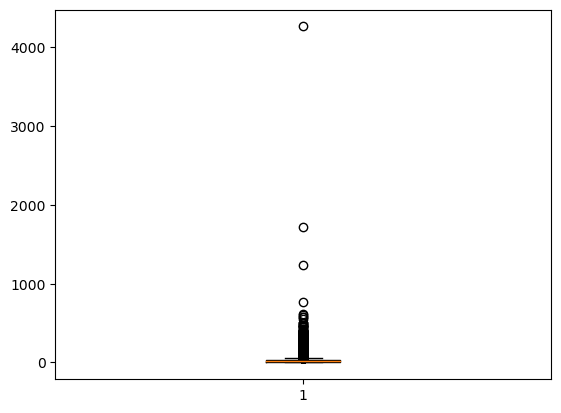

In [38]:
plt.boxplot(df['fare_amount'])
plt.show()

In [39]:
for col in ['trip_distance','duration','total_amount','trip_distance']:
    q1 = df[col].quantile(0.25)
    q2 = df[col].quantile(0.75)
    
    IQR = q2 -q1
    
    lb = q1 - 1.5*IQR
    ub = q2 + 1.5*IQR
    
    df = df[(df[col] >= lb) & (df[col] <=ub)]

In [40]:
df.shape

(1072131, 6)

In [41]:
df.head()

,passenger_count,trip_distance,payment_type,fare_amount,total_amount,duration
0,1,1.20,card,6.0,11.27,4.800000
1,1,1.20,card,7.0,12.30,7.416667
2,1,0.60,card,6.0,10.80,6.183333
3,1,0.80,card,5.5,8.16,4.850000
5,1,0.03,cash,2.5,3.80,0.883333


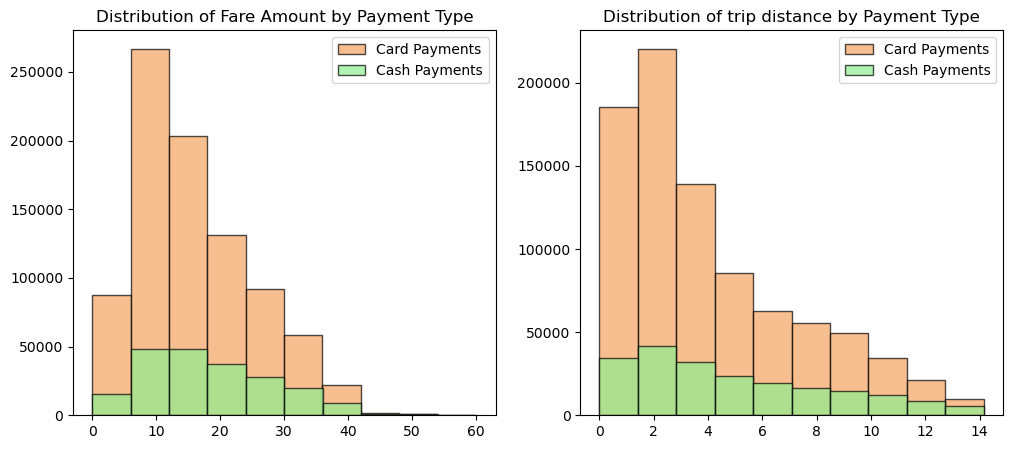

In [42]:
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)

plt.hist(df[df['payment_type'] == 'card']["fare_amount"], color='sandybrown', alpha=0.7,edgecolor="black", label='Card Payments')
plt.hist(df[df['payment_type'] == 'cash']["fare_amount"], color='lightgreen', alpha=0.7,edgecolor="black", label='Cash Payments')
plt.title('Distribution of Fare Amount by Payment Type')
plt.legend()

plt.subplot(1,2,2)
plt.hist(df[df['payment_type'] == 'card']["trip_distance"], color='sandybrown', alpha=0.7,edgecolor="black", label='Card Payments')
plt.hist(df[df['payment_type'] == 'cash']["trip_distance"], color='lightgreen', alpha=0.7,edgecolor="black", label='Cash Payments')
plt.title('Distribution of trip distance by Payment Type')
plt.legend()

plt.show()

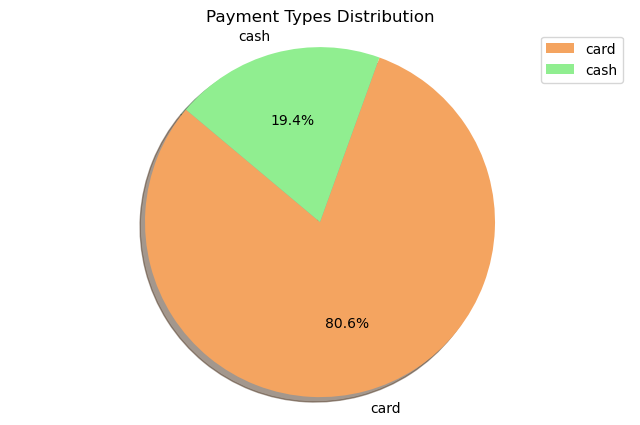

In [43]:
sizes = df['payment_type'].value_counts(normalize=True)
labels = sizes.index
colors = ['sandybrown', 'lightgreen']

plt.figure(figsize=(8, 5))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, shadow=True)


plt.title('Payment Types Distribution')
plt.legend(loc='best')
plt.axis('equal')  

plt.show()

In [44]:
passenger_count = df.groupby(['payment_type','passenger_count'])["passenger_count"].count().unstack()


In [45]:
passenger_count


passenger_count,1,2,3,4,5,6
payment_type,,,,,,
card,454464,172611,72881,42288,72748,49081
cash,93602,43693,21440,14525,20164,14634


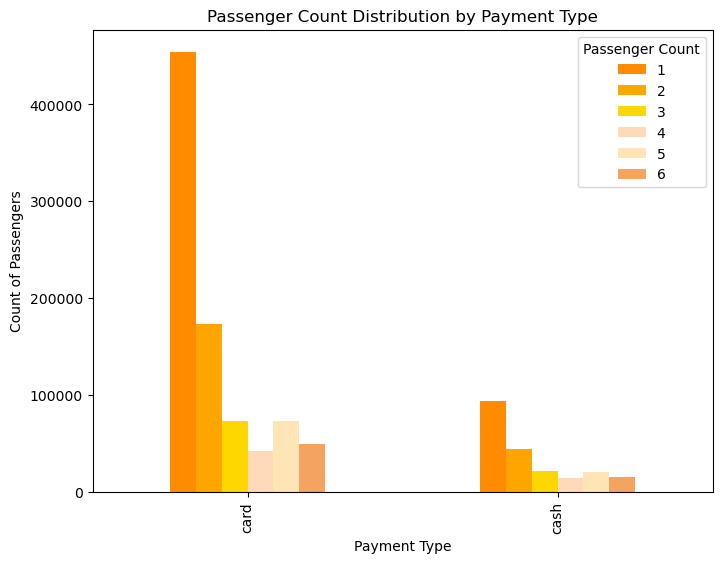

In [46]:

# Plot
passenger_count.plot(kind='bar', stacked=False, figsize=(8, 6) ,color = ["darkorange" ,"orange","gold","peachpuff","moccasin","sandybrown"] )

# Add title and labels
plt.title('Passenger Count Distribution by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Count of Passengers')

# Show plot
plt.legend(title='Passenger Count')
plt.show()


In [47]:
df

,passenger_count,trip_distance,payment_type,fare_amount,total_amount,duration
0,1,1.20,card,6.0,11.27,4.800000
1,1,1.20,card,7.0,12.30,7.416667
2,1,0.60,card,6.0,10.80,6.183333
3,1,0.80,card,5.5,8.16,4.850000
5,1,0.03,cash,2.5,3.80,0.883333
...,...,...,...,...,...,...
6339486,1,4.70,card,23.0,30.80,36.550000
6339497,1,9.23,cash,30.0,39.92,27.066667
6339507,5,4.47,card,23.5,28.80,36.483333
6339518,1,1.95,card,11.0,12.30,14.450000


# hypthesis testing

null hypthesis - there is no difference in average fair between customers who pay through credit card and customers who pay                      through cash

alternative hypothesis - there is difference in average fair between customers who pay through credit card and customers who pay                          through cash

In [48]:
card_sample = df[df['payment_type']=="card"]['fare_amount']
cash_sample = df[df['payment_type']=="cash"]['fare_amount']



In [49]:
t_stats,p_value = st.ttest_ind(a = card_sample,b = cash_sample, equal_var = False)
print('T statistic',t_stats,'P value',p_value)

T statistic -101.5255114536642 P value 0.0


solution 

With such a low p-value, we reject the null hypothesis. This means that there is a significant difference in the average fare between customers who pay through credit card and customers who pay through cash.